<a href="https://colab.research.google.com/github/melnotte/telecom-x-customer-churn-analysis/blob/main/telecom_x_customer_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Telecom X: Customer Churn Analysis
### Project Overview & Exploratory Data Analysis

### 1. Introduction

The telecommunications industry faces a significant challenge: Customer Churn. Telecom X has observed an increasing rate of service cancellations, which directly impacts long-term revenue and market stability.

The goal of this project is to act as a Data Analysis Assistant to extract, clean, and explore the company's customer data. By identifying the demographic patterns, service types, and billing behaviors associated with "churn," we aim to provide the Data Science team with a high-quality dataset and actionable insights to build predictive models and retention strategies.

### 2. Project Goals
* **ETL Implementation:** Efficiently import data from the Telecom X JSON API and transform it into a structured Pandas DataFrame.

* **Data Integrity:** Perform rigorous data cleaning to handle missing values, duplicates, and formatting inconsistencies.

* **Feature Engineering:** Derive new metrics, such as daily billing, to gain deeper granular insights.

* **Exploratory Data Analysis (EDA):** Visualize correlations between customer variables (tenure, contract type, payment method) and the likelihood of evasion.

* **Strategic Reporting:** Summarize findings into a professional report with data-driven recommendations.

# Project Index


## Data Acquisition: Importing libraries and fetching JSON data from the API



In [45]:
import requests
import pandas as pd
import json

In [46]:
# URL del archivo JSON raw en GitHub
json_url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'

try:
    # Realizar la solicitud HTTP para obtener el contenido del JSON
    response = requests.get(json_url)
    response.raise_for_status()

    # Cargar el contenido JSON en un diccionario de Python
    telecom_data = response.json()

    # Convertir el diccionario JSON a un DataFrame de pandas
    df_telecom = pd.DataFrame(telecom_data)

    print("Datos JSON cargados exitosamente en df_telecom.")

except requests.exceptions.RequestException as e:
    print(f"Error al intentar obtener los datos de la URL: {e}")
except json.JSONDecodeError as e:
    print(f"Error al decodificar el JSON: {e}")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")


Datos JSON cargados exitosamente en df_telecom.


## Data Understanding: Checking types, dimensions, and variable definitions



In [47]:
df_telecom.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [48]:
df_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [49]:
df_telecom.describe()

,customerID,Churn,customer,phone,internet,account
count,7267,7267,7267,7267,7267,7267
unique,7267,3,891,3,129,6931
top,9995-HOTOH,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
freq,1,5174,223,3495,1581,6


In [50]:
df_telecom = pd.json_normalize(telecom_data)
df_telecom.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [51]:
df_telecom.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [52]:
df_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [53]:
df_telecom.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente

## Data Cleaning & Preprocessing: Handling nulls, duplicates, and category errors



In [54]:
df_telecom.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [55]:
df_telecom.duplicated().sum()

np.int64(0)

In [56]:
columnas_objeto = df_telecom.select_dtypes(include=['object']).columns

for col in columnas_objeto:
    if col != 'customerID':
      print(f"{col}: {df_telecom[col].unique()}")

Churn: ['No' 'Yes' '']
customer.gender: ['Female' 'Male']
customer.Partner: ['Yes' 'No']
customer.Dependents: ['Yes' 'No']
phone.PhoneService: ['Yes' 'No']
phone.MultipleLines: ['No' 'Yes' 'No phone service']
internet.InternetService: ['DSL' 'Fiber optic' 'No']
internet.OnlineSecurity: ['No' 'Yes' 'No internet service']
internet.OnlineBackup: ['Yes' 'No' 'No internet service']
internet.DeviceProtection: ['No' 'Yes' 'No internet service']
internet.TechSupport: ['Yes' 'No' 'No internet service']
internet.StreamingTV: ['Yes' 'No' 'No internet service']
internet.StreamingMovies: ['No' 'Yes' 'No internet service']
account.Contract: ['One year' 'Month-to-month' 'Two year']
account.PaperlessBilling: ['Yes' 'No']
account.PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
account.Charges.Total: ['593.3' '542.4' '280.85' ... '742.9' '4627.65' '3707.6']


In [57]:
# 1. Eliminar filas donde Churn está vacío
print(f"Filas antes de limpiar Churn: {len(df_telecom)}")
df_telecom = df_telecom[df_telecom['Churn'] != '']
print(f"Filas después de limpiar Churn: {len(df_telecom)}")

Filas antes de limpiar Churn: 7267
Filas después de limpiar Churn: 7043


In [58]:
df_telecom['account.Charges.Total'] = pd.to_numeric(df_telecom['account.Charges.Total'], errors='coerce')
df_telecom['account.Charges.Total'] = df_telecom['account.Charges.Total'].fillna(0)

df_telecom.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   object 
 1

In [59]:
# 3. Estandarizar valores "No internet/phone service" a "No"
cols_a_limpiar = [
    'phone.MultipleLines', 'internet.OnlineSecurity', 'internet.OnlineBackup',
    'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV',
    'internet.StreamingMovies'
]

for col in cols_a_limpiar:
    df_telecom[col] = df_telecom[col].replace({'No internet service': 'No', 'No phone service': 'No'})

## Feature Engineering: Creating the Daily_Charges column and standardizing labels

In [60]:
df_telecom['daily_charges'] = (df_telecom['account.Charges.Monthly'] / 30).round(2)

df_telecom.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,daily_charges
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [61]:
cols_binarias = [
    'Churn', 'customer.Partner', 'customer.Dependents',
    'phone.PhoneService', 'phone.MultipleLines', 'internet.OnlineSecurity',
    'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport',
    'internet.StreamingTV', 'internet.StreamingMovies', 'account.PaperlessBilling'
]

for col in cols_binarias:
    df_telecom[col] = df_telecom[col].map({'Yes': 1, 'No': 0})

df_telecom[cols_binarias].head()

,Churn,customer.Partner,customer.Dependents,phone.PhoneService,phone.MultipleLines,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.PaperlessBilling
0,0,1,1,1,0,0,1,0,1,1,0,1
1,0,0,0,1,1,0,0,0,0,0,1,0
2,1,0,0,1,0,0,0,1,0,0,0,1
3,1,1,0,1,0,0,1,1,0,1,1,1
4,1,1,0,1,0,0,0,0,1,1,0,1


## Descriptive Statistics: Analyzing means, medians, and distributions

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

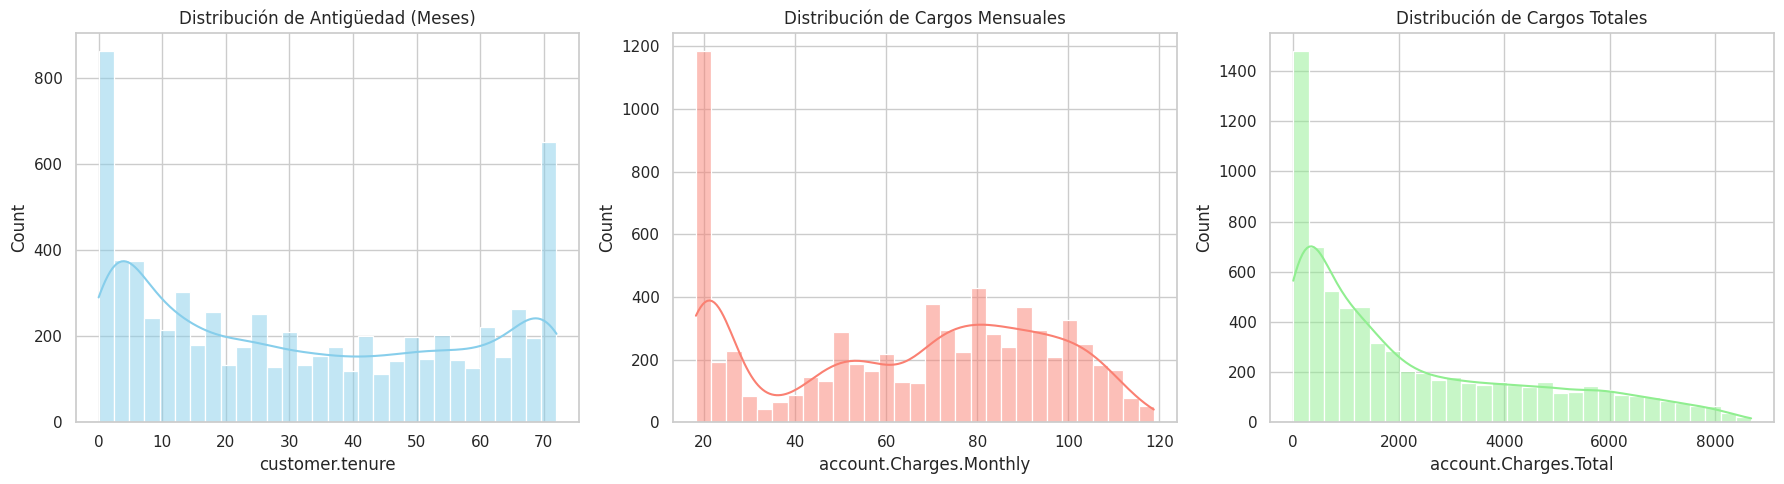

In [63]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma de Antigüedad
sns.histplot(df_telecom['customer.tenure'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Antigüedad (Meses)')

# Histograma de Cargos Mensuales
sns.histplot(df_telecom['account.Charges.Monthly'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución de Cargos Mensuales')

# Histograma de Cargos Totales
sns.histplot(df_telecom['account.Charges.Total'], bins=30, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribución de Cargos Totales')

plt.tight_layout()
plt.show()

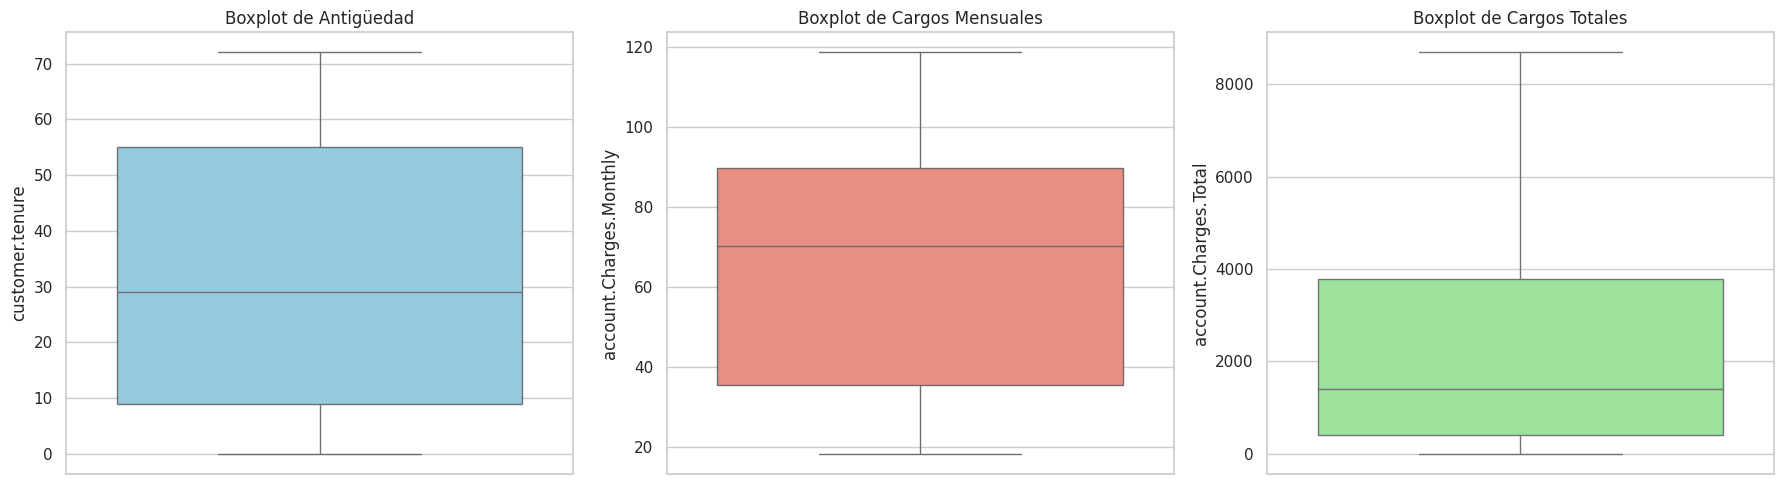

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df_telecom['customer.tenure'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot de Antigüedad')

sns.boxplot(y=df_telecom['account.Charges.Monthly'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot de Cargos Mensuales')

sns.boxplot(y=df_telecom['account.Charges.Total'], ax=axes[2], color='lightgreen')
axes[2].set_title('Boxplot de Cargos Totales')

plt.tight_layout()
plt.show()

In [65]:
df_telecom.describe().T

,count,mean,std,min,25%,50%,75%,max
Churn,7043.0,0.265370,0.441561,0.00,0.00,0.00,1.00,1.00
customer.SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
customer.Partner,7043.0,0.483033,0.499748,0.00,0.00,0.00,1.00,1.00
customer.Dependents,7043.0,0.299588,0.458110,0.00,0.00,0.00,1.00,1.00
customer.tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
phone.PhoneService,7043.0,0.903166,0.295752,0.00,1.00,1.00,1.00,1.00
phone.MultipleLines,7043.0,0.421837,0.493888,0.00,0.00,0.00,1.00,1.00
internet.OnlineSecurity,7043.0,0.286668,0.452237,0.00,0.00,0.00,1.00,1.00
internet.OnlineBackup,7043.0,0.344881,0.475363,0.00,0.00,0.00,1.00,1.00
internet.DeviceProtection,7043.0,0.343888,0.475038,0.00,0.00,0.00,1.00,1.00


## Target Variable Analysis: Visualizing the global Churn rate

In [84]:
import plotly.express as px
import plotly.graph_objects as go

In [93]:
colors = ["#0072B2", "#E69F00"]
sns.set_palette(sns.color_palette(colors))

# Configuración estética general
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

In [103]:
# Paleta global
PALETA_CHURN = {'Permaneció': '#0072B2', 'Se dio de baja': '#E69F00'}

# Creamos una columna definitiva para etiquetas en el dataframe principal
df_telecom['Churn_Label'] = df_telecom['Churn'].map({0: 'Permaneció', 1: 'Se dio de baja'})

In [104]:
churn_resumen = df_telecom['Churn_Label'].value_counts().reset_index()
churn_resumen.columns = ['Estado', 'Total']

fig_dona = px.pie(
    churn_resumen,
    values='Total',
    names='Estado',
    hole=0.5,
    color='Estado',
    color_discrete_map=PALETA_CHURN,
    title='<b>Estado de Retención de Clientes</b>'
)

fig_dona.update_traces(
    textinfo='percent+label',
    marker=dict(line=dict(color='#FFFFFF', width=2)),
    textposition='inside',
    insidetextorientation='horizontal'
)

fig_dona.update_layout(
    annotations=[dict(text='Churn Rate', x=0.5, y=0.5, font_size=20, showarrow=False)],
    showlegend=True
)

fig_dona.show()

In [106]:
fig_barras = px.bar(
    churn_resumen,
    x='Estado',
    y='Total',
    color='Estado',
    color_discrete_map=PALETA_CHURN,
    title='<b>Volumen Total de Clientes</b>',
    text_auto='.2s'
)

fig_barras.update_layout(
    xaxis_title="Estado del Cliente",
    yaxis_title="Cantidad de Clientes",
    showlegend=False,
    plot_bgcolor='rgba(0,0,0,0)',
    bargap=0.4
)

total_clientes = churn_resumen['Total'].sum()

fig_barras.add_annotation(
    text=f"Total de la base: {total_clientes} clientes",
    xref="paper", yref="paper",
    x=1, y=1.1, showarrow=False, font=dict(size=12, color="gray")
)

fig_barras.show()

##Multivariate Analysis: * Churn vs. Categorical Variables (Gender, Contract, etc.)

In [110]:
def plot_churn_categorical(df, col_name, title):
    df_grouped = df.groupby([col_name, 'Churn_Label']).size().reset_index(name='Total')
    df_grouped['Porcentaje'] = df_grouped.groupby(col_name)['Total'].transform(lambda x: x / x.sum() * 100)

    fig = px.bar(
        df_grouped, x=col_name, y='Porcentaje', color='Churn_Label',
        color_discrete_map=PALETA_CHURN,
        title=f'<b>{title}</b>', text_auto='.1f'
    )
    fig.update_layout(yaxis_title="Porcentaje (%)", barmode='stack', plot_bgcolor='rgba(0,0,0,0)')
    fig.show()

plot_churn_categorical(df_telecom, 'account.Contract', 'Evasión por Tipo de Contrato')
plot_churn_categorical(df_telecom, 'account.PaymentMethod', 'Evasión por Método de Pago')
plot_churn_categorical(df_telecom, 'internet.InternetService', 'Evasión por Servicio de Internet')
plot_churn_categorical(df_telecom, 'customer.gender', 'Evasión por Género')

###Churn vs. Numerical Variables (Tenure, Total Spent)

In [111]:
import plotly.figure_factory as ff

In [121]:
fig_hist_tenure = px.histogram(
    df_telecom,
    x="customer.tenure",
    color="Churn_Label",
    nbins=30,
    color_discrete_map=PALETA_CHURN,
    barmode='overlay',
    title='<b>Distribución de Antigüedad por Estado de Churn</b>',
    labels={'customer.tenure': 'Meses de Antigüedad', 'count': 'Número de Clientes'}
)

fig_hist_tenure.update_traces(opacity=0.75)
fig_hist_tenure.update_layout(plot_bgcolor='rgba(0,0,0,0)', bargap=0.1)
fig_hist_tenure.show()

In [118]:
fig_box = px.box(
    df_telecom,
    x='Churn_Label',
    y='account.Charges.Monthly',
    color='Churn_Label',
    color_discrete_map=PALETA_CHURN,
    points="all",
    title='<b>Distribución de Cargos Mensuales por Churn</b>'
)

fig_box.update_layout(
    xaxis_title="Estado del Cliente",
    yaxis_title="Cargos Mensuales ($)",
    showlegend=False,
    plot_bgcolor='rgba(0,0,0,0)'
)
fig_box.show()

In [122]:
df_corr = df_telecom.copy()

cols_interes = [
    'Churn',
    'customer.tenure',
    'account.Charges.Monthly',
    'account.Charges.Total'
]

matriz_corr = df_corr[cols_interes].corr()

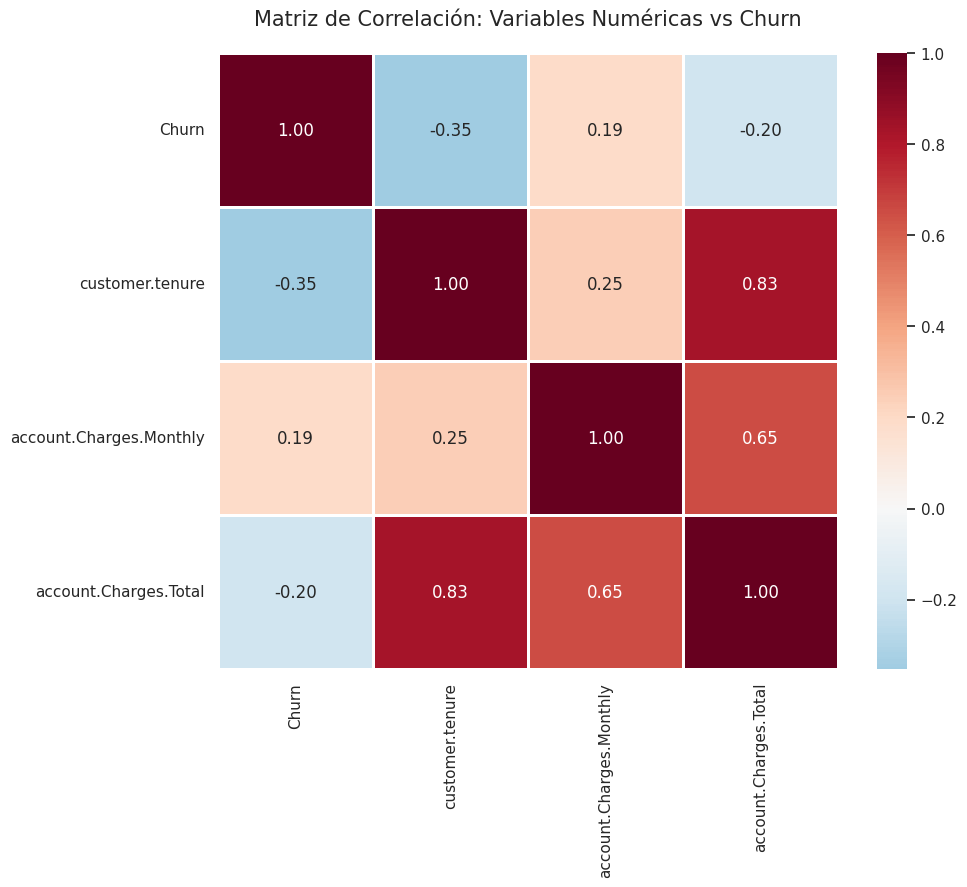

In [123]:
plt.figure(figsize=(10, 8))

sns.heatmap(matriz_corr,
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0,
            linewidths=2,
            linecolor='white')

plt.title('Matriz de Correlación: Variables Numéricas vs Churn', fontsize=15, pad=20)
plt.show()

##Final Report & Insights: Conclusions and strategic recommendations



> The primary objective of this analysis is to identify the key drivers behind customer attrition (Churn) at Telecom X. Customer churn poses a significant threat to long-term profitability and market stability. By analyzing demographic data, service types, and billing behaviors, this report aims to provide actionable insights to improve customer retention and optimize marketing strategies.


### Data Cleaning & Processing


To ensure data integrity, the following steps were performed within the notebook:

* **Data Integration:** Imported raw customer data from JSON and tabular formats.

* **Handling Missing Values:** Identified and treated null values, particularly in the TotalCharges column, ensuring numerical consistency.

* **Data Transformation:** Converted categorical variables into formats suitable for analysis and normalized numerical features like tenure and MonthlyCharges.

* **Feature Engineering:** Organized data into logical segments (Demographics, Services, and Account information) to facilitate deeper correlation analysis.


### Exploratory Data Analysis (EDA)
Our exploration revealed several critical patterns regarding why customers leave:

* **Contract Type:** "Month-to-month" contracts show the highest churn rate compared to one or two-year commitments.

* **Payment Methods:** Customers using "Electronic Check" are significantly more likely to churn than those using automated or mailed methods.

* **Service Impact:** Fiber optic users exhibit a higher churn rate than DSL users, suggesting potential issues with service pricing or perceived value in that segment.

* **Tenure Trends:** There is a high risk of "early churn" within the first few months. However, customers who surpass the initial phase show high long-term loyalty.

* **Correlation:** The Heatmap analysis confirmed a strong correlation between contract duration, total charges, and the likelihood of churn.


### Conclusions & Insights
The data suggests that churn is not random but tied to specific high-risk categories. The parity in gender indicates that churn is driven by service experience and billing structure rather than demographic traits. The "early-stage" churn is the most critical window for intervention; if a customer survives the first year, their lifetime value (LTV) increases exponentially.

* Strategic Recommendations:
    * Investigate the pricing structure of Fiber Optic plans. Since these users have higher monthly charges, the company should consider "bundling" Fiber with free Tech Support or Online Security for the first 6 months to increase the perceived value and reduce early-stage churn.
    * Actively target "Month-to-month" users with incentives (e.g., a one-month discount) to switch to One-year or Two-year contracts, as the data shows these customers have significantly higher retention rates.
    * Automate the billing process for "Electronic Check" users. Transitioning these customers to Credit Card (automatic) or Bank Transfer can reduce "accidental" churn caused by manual payment delays or expired checks.
    * Given that churn is highest at the beginning of the tenure, implement a "Customer Success" check-in at the 30-day and 90-day marks to ensure the service is meeting expectations.
    * Study the cohort of long-term customers (high tenure). Identify if they share specific service combinations (like having both Phone and Internet) and promote those specific "sticky" bundles to new users.